I made modelling and nex step decisions and claude helped me quickly recode the model to run efficiently to get a new baseline

* Updated with features matching CMIP6 models
* Using fixed data

In [1]:
### Target: County-Level hourly MW

In [2]:
##!pip install shap lightgbm pandas pyarrow --quiet

In [3]:
### Cell 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.metrics import mean_squared_error
sns.set(style="darkgrid")

In [4]:
### Cell 3 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
### Cell 4 — Load Data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/full_hist_attr/'
    return pd.read_parquet(directory + filename + '.parquet')

In [6]:
df = read_file('full_data_18to23_asofFeb25_1')

In [7]:
df.columns

Index(['Date', 'County', 'dpt_afternoon_k_pop', 'hdd65', 'wind_peak_ms_mean',
       'wind_low_ms_mean', 'spfh_peak_kgkg_pop', 'wind_peak_ms_pop', 'cdd75',
       'tavg_k', 'dpt_afternoon_k_mean', 'cloud_cover_pct_pop',
       'dpt_morning_k_mean', 'tmax_k_pop', 'cdd65_pop', 'cloud_cover_pct_mean',
       'tmin_k', 'hdd65_pop', 'dpt_morning_k_pop', 'wind_low_ms_pop',
       'trange_k', 'cdd65', 'tmin_k_pop', 'cdd75_pop', 'spfh_peak_kgkg_mean',
       'tmax_k', 'real_data_urma', 'staying_total', 'entering_total',
       'leaving_total', 'real_data_commuting', 'cuml_count', 'cuml_sq_foot',
       'cuml_utility_cap', 'cuml_dc_load', 'real_data_data_centers',
       'Total_Daily_Electricity_Usage', 'hour_of_max',
       'Max_Daily_Electricity_Usage', 'Public Level 1',
       'Shared Private Level 1', 'Public Level 2', 'Shared Private Level 2',
       'Public DC Fast', 'Shared Private DC Fast', 'Total',
       'real_data_ev_charging', 'BEV', 'PHEV', 'FCEV',
       'real_data_ev_poplution', 

In [8]:
### Cell 4 — Load Data
def read_csv(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/csv/2_12_cleaned_csv/'
    return pd.read_csv(directory + filename + '.csv')

## 2017 BASELINE

In [9]:
elec = read_csv('county_electricity_demand')
elec.head(3)

,timestamp,Alameda,Alpine,Amador,Butte,Calaveras,Colusa,Contra Costa,Del Norte,El Dorado,...,Sonoma,Stanislaus,Sutter,Tehama,Trinity,Tulare,Tuolumne,Ventura,Yolo,Yuba
0,2016-01-01 00:00:00+00:00,1176.275794,0.812014,26.598339,162.300902,32.192157,15.268580,1062.423344,25.020711,133.662747,...,358.862354,359.101087,68.594283,46.700827,9.284875,300.275290,41.835854,576.225204,153.936470,53.236849
1,2016-01-01 01:00:00+00:00,1190.669213,0.752825,26.923826,164.286880,32.586073,15.455413,1075.423577,26.634949,135.222954,...,363.253536,378.357263,69.433766,45.640673,9.688812,314.084688,40.801315,605.631208,155.826528,53.893551
2,2016-01-01 02:00:00+00:00,1316.228479,0.832196,29.763021,181.611371,36.022361,17.085228,1188.829870,28.915939,149.481856,...,401.559593,421.932353,76.755706,50.452193,10.849582,357.686718,45.118873,692.614804,172.260811,59.575321


In [10]:
pop17 = read_csv('pop_housing_data')
pop17.head(3)

,state_county,date_recorded,total_pop,household_pop,group_quarters_pop,total_households,single_detached,single_attached,two_to_four,five_plus,mobile_homes,occupied,vacancy_rate,person_per_household
0,Alameda,1/1/11,1527169,1485580,41589,583581,310375,44511,65370,155509,7816,546259,0.064,2.72
1,Alameda,1/1/12,1549193,1507025,42168,585757,311507,44989,65377,156089,7795,549045,0.063,2.74
2,Alameda,1/1/13,1575139,1531715,43424,589036,312769,45539,65449,157507,7772,554877,0.058,2.76


In [11]:
import pandas as pd
import numpy as np

# Load your sheets
elec = read_csv('county_electricity_demand')
pop17 = read_csv('pop_housing_data')

# Filter to 2017
elec['timestamp'] = pd.to_datetime(elec['timestamp'], format='mixed')
pop17['date_recorded'] = pd.to_datetime(pop17['date_recorded'], format='mixed')

elec_2017 = elec[elec['timestamp'].dt.year == 2017]
pop_2017 = pop17[pop17['date_recorded'].dt.year == 2017]

# Reshape electricity wide → long
county_cols = [c for c in elec_2017.columns if c != 'timestamp']
elec_long = elec_2017.melt(id_vars=['timestamp'], value_vars=county_cols,
                             var_name='county', value_name='max_daily_electricity')
elec_long['date'] = pd.to_datetime(elec_long['timestamp'].dt.date)

# Reshape population
pop_clean = pop_2017[['state_county', 'date_recorded', 'total_pop']].copy()
pop_clean['county'] = pop_clean['state_county'].str.replace('California', '').str.strip()
pop_clean['date'] = pd.to_datetime(pop_clean['date_recorded'].dt.date)

# Merge
merged = elec_long.merge(pop_clean[['date', 'county', 'total_pop']], on=['date', 'county'], how='left')
merged = merged.sort_values('date')
merged['total_pop'] = merged.groupby('county')['total_pop'].ffill()

# Annual baseline (per capita)
baseline_annual_2017 = merged.groupby('county').apply(
    lambda x: (x['max_daily_electricity'] / x['total_pop']).mean(),
    include_groups=False
).reset_index()
baseline_annual_2017.columns = ['county', 'baseline_mw_per_capita_2017']

# Monthly baseline (pop-weighted)
merged['month'] = merged['date'].dt.month
monthly_baseline = merged.groupby(['county', 'month']).apply(
    lambda x: np.average(x['max_daily_electricity'], weights=x['total_pop']),
    include_groups=False
).reset_index()
monthly_baseline.columns = ['county', 'month', 'baseline_mw_monthly_2017']

print("✓ Annual baseline:")
print(baseline_annual_2017.head())
print("\n✓ Monthly baseline:")
print(monthly_baseline.head(15))

✓ Annual baseline:
      county  baseline_mw_per_capita_2017
0    Alameda                     0.000772
1     Alpine                     0.000745
2     Amador                     0.000783
3      Butte                     0.000792
4  Calaveras                     0.000806

✓ Monthly baseline:
     county  month  baseline_mw_monthly_2017
0   Alameda      1               1229.178341
1   Alameda      2               1208.897972
2   Alameda      3               1143.373823
3   Alameda      4               1142.775683
4   Alameda      5               1255.646994
5   Alameda      6               1429.877871
6   Alameda      7               1521.152816
7   Alameda      8               1502.519448
8   Alameda      9               1400.782646
9   Alameda     10               1176.346007
10  Alameda     11               1147.231107
11  Alameda     12               1192.896290
12   Alpine      1                  0.840117
13   Alpine      2                  0.813094
14   Alpine      3               

In [12]:
### Cell 5 — Rename Columns
df = df.rename(columns={
    'Date':  'date',
    'County': 'county',
    'BEV':   'bev',
    'PHEV':  'phev',
    'FCEV':  'fcev',
    'Max_Daily_Electricity_Usage': 'max_daily_electricity',
    'Per_Capita_Personal_Income_Adjusted': 'per_cap_income',
    'Total': 'total_ev_charge'
})

In [13]:
### Cell 6 — Target Engineering (BEFORE split)
df['date'] = pd.to_datetime(df['date'])
df['max_elec_per_capita']     = df['max_daily_electricity'] / df['total_pop']
df['max_elec_per_capita_log'] = np.log(df['max_elec_per_capita'])

target = 'max_elec_per_capita_log'

print(df.shape)


(127078, 74)


In [14]:
# Use pre-computed 2017 baselines (no leakage)
baseline_annual_2017 = baseline_annual_2017  # Already loaded
baseline_monthly_2017 = monthly_baseline     # Already loaded

# Merge annual baseline
df = df.merge(baseline_annual_2017, on='county', how='left')

# Merge monthly baseline
df['month'] = df['date'].dt.month
df = df.merge(baseline_monthly_2017, on=['county', 'month'], how='left')

print("✓ Merged 2017 baselines")
print(f"Missing annual: {df['baseline_mw_per_capita_2017'].isna().sum()}")
print(f"Missing monthly: {df['baseline_mw_monthly_2017'].isna().sum()}")

✓ Merged 2017 baselines
Missing annual: 0
Missing monthly: 0


In [15]:
# df["total_ev_chg/pop"] = (df["total_ev_charge"])/df["total_pop"]

In [16]:
ROLLING_SPECS = [
    ("cdd65_pop_roll5",       "cdd65_pop",  5,  "sum"),
    ("hdd65_pop_roll5",       "hdd65_pop",  5,  "sum"),
    ("tmax_k_pop_roll5_max",  "tmax_k_pop", 5,  "max"),
    ("tmax_k_pop_roll7_mean", "tmax_k_pop", 7,  "mean"),

]

def add_rolling_features(df):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)
    for new_col, src_col, window, agg in ROLLING_SPECS:
        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )
    return df

In [17]:
# Compute 2019 mobility baseline before dropping the columns
mobility_baseline = (
    df[df['date'].dt.year == 2019]
    .groupby(['county', 'day_of_week'])[['staying_total', 'entering_total', 'leaving_total']]
    .median()
    .reset_index()
)
print("Mobility baseline shape:", mobility_baseline.shape)


Mobility baseline shape: (406, 5)


In [18]:
df = add_rolling_features(df)

# Replace mobility with frozen 2019 baseline
df = df.drop(columns=['staying_total', 'entering_total', 'leaving_total'])
df = df.merge(mobility_baseline, on=['county', 'day_of_week'], how='left')


In [19]:
### Dew Point Depression Feature
import numpy as np

def add_dpd_features(df):
    P = 101325  # standard pressure Pa
    w = df['spfh_peak_kgkg_pop']

    # specific humidity → vapor pressure
    e = (w * P) / (0.622 + w)

    # vapor pressure → dew point (K)
    dpt_c = 243.04 * np.log(e / 611.2) / (17.625 - np.log(e / 611.2))
    df['dpt_derived_k'] = dpt_c + 273.15

    # dew point depression (K) — large = dry, small = humid
    df['dpd_k'] = (df['tmax_k_pop'] - df['dpt_derived_k']).clip(lower=0)

    # rolling 5-day mean depression
    df = df.sort_values(['county', 'date'])
    df['dpd_k_roll5'] = (df
        .groupby('county')['dpd_k']
        .transform(lambda x: x.rolling(5, min_periods=1).mean()))

    return df

df = add_dpd_features(df)

print(f"dpd_k stats:\n{df['dpd_k'].describe()}")

dpd_k stats:
count    127078.000000
mean         15.181825
std           8.168411
min           0.000000
25%           8.577026
50%          14.242157
75%          21.110504
max          52.180115
Name: dpd_k, dtype: float64


In [20]:
df.columns.to_list()

['date',
 'county',
 'dpt_afternoon_k_pop',
 'hdd65',
 'wind_peak_ms_mean',
 'wind_low_ms_mean',
 'spfh_peak_kgkg_pop',
 'wind_peak_ms_pop',
 'cdd75',
 'tavg_k',
 'dpt_afternoon_k_mean',
 'cloud_cover_pct_pop',
 'dpt_morning_k_mean',
 'tmax_k_pop',
 'cdd65_pop',
 'cloud_cover_pct_mean',
 'tmin_k',
 'hdd65_pop',
 'dpt_morning_k_pop',
 'wind_low_ms_pop',
 'trange_k',
 'cdd65',
 'tmin_k_pop',
 'cdd75_pop',
 'spfh_peak_kgkg_mean',
 'tmax_k',
 'real_data_urma',
 'real_data_commuting',
 'cuml_count',
 'cuml_sq_foot',
 'cuml_utility_cap',
 'cuml_dc_load',
 'real_data_data_centers',
 'Total_Daily_Electricity_Usage',
 'hour_of_max',
 'max_daily_electricity',
 'Public Level 1',
 'Shared Private Level 1',
 'Public Level 2',
 'Shared Private Level 2',
 'Public DC Fast',
 'Shared Private DC Fast',
 'total_ev_charge',
 'real_data_ev_charging',
 'bev',
 'phev',
 'fcev',
 'real_data_ev_poplution',
 'per_cap_income',
 'real_data_income',
 'total_pop',
 'household_pop',
 'group_quarters_pop',
 'total_ho

In [21]:
# Split
train_df = df[df['date'].dt.year <= 2021].copy()
val_df   = df[df['date'].dt.year == 2022].copy()
test_df  = df[df['date'].dt.year == 2023].copy()

print(f"Train: {train_df.shape}  ({train_df['date'].dt.year.min()}–{train_df['date'].dt.year.max()})")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")


Train: (84738, 83)  (2018–2021)
Val:   (21170, 83)
Test:  (21170, 83)


In [27]:
### Cell 8 — Features
selected_features = [
    # CATEGORICAL
    #"county",
    "day_of_week",
    # CALENDAR
    "quarter",
    "month",
    "is_holiday",
    # TEMPERATURE
    "tmax_k_pop",
    "tmin_k_pop",
    "trange_k",
    # DEGREE DAYS
    "hdd65_pop",
    "cdd65_pop",
    "cdd75_pop",
    # ROLLING WEATHER
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "tmax_k_pop_roll5_max",
    "tmax_k_pop_roll7_mean",
    # HUMIDITY
    "spfh_peak_kgkg_pop",
    # WIND
    "wind_peak_ms_pop",
    # MOBILITY
    # "staying_total",
    # "entering_total",
    # "leaving_total",
    # DATA CENTERS
    "cuml_count",
    "cuml_sq_foot",
    "cuml_utility_cap",
    "cuml_dc_load",
    # EVs
     "bev",
    #   "phev",
    #  "fcev",
      # "total_ev_pop",
    # SOCIOECONOMIC
    "per_cap_income",
    "total_pop",
    ## MW / county / pop
    "baseline_mw_per_capita_2017",      # Changed from 2018
    "baseline_mw_monthly_2017",
    ##dpd_k
    'dpd_k',
    'dpd_k_roll5',
]

cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 27


In [23]:
# selected_features=["month", "total_pop", "est_median_income", "cuml_utility_cap", "cdd65_pop", "hdd65_pop", "spfh_peak_kgkg_pop", "cloud_cover_pct_pop", "wind_low_ms_pop", "wind_peak_ms_pop", "total_ev_pop"]

In [28]:
cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 27


In [29]:
### Cell 9 — Train Model
def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        val_df[c]   = val_df[c].astype("category")
        val_df[c]   = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_model(train_df, val_df, features, params):
    X_train, y_train = train_df[features], train_df[target]
    X_val,   y_val   = val_df[features],   val_df[target]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train),
            (X_val,   y_val),],
        eval_names=["train","val"],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    preds_val = model.predict(X_val, num_iteration=model.best_iteration_)
    rmse_val  = rmse(y_val, preds_val)
    return model, rmse_val, preds_val, model.best_iteration_

params = dict(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 — add this
    reg_lambda=1.0,     # L2 — add this
    random_state=42,
)

train_df, val_df = set_and_align_categories(train_df, val_df)

model, rmse_val, preds_val, best_iter = run_model(train_df, val_df, selected_features, params)

print(f"""
rmse_val (log per capita): {rmse_val:.6f}
best_iter:                 {best_iter}
""")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009656 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5696
[LightGBM] [Info] Number of data points in the train set: 84738, number of used features: 27
[LightGBM] [Info] Start training from score -6.941684
[300]	train's rmse: 0.0775463	train's l2: 0.00601343	val's rmse: 0.130648	val's l2: 0.017069
[600]	train's rmse: 0.071925	train's l2: 0.00517321	val's rmse: 0.126047	val's l2: 0.0158878
[900]	train's rmse: 0.0687932	train's l2: 0.00473251	val's rmse: 0.125029	val's l2: 0.0156322
[1200]	train's rmse: 0.0663174	train's l2: 0.00439799	val's rmse: 0.124383	val's l2: 0.0154711
[1500]	train's rmse: 0.0641904	train's l2: 0.00412041	val's rmse: 0.12385	val's l2: 0.0153387
[1800]	train's rmse: 0.0622642	train's l2: 0.00387682	val's rmse: 0.123483	val's l2: 0.0152481
[2100]	train's rmse: 0.060534

In [30]:
### Cell 10 — MWh Metrics
val_df = val_df.copy()
val_df['preds_mwh'] = np.exp(preds_val) * val_df['total_pop']
val_df['actual_mwh'] = np.exp(val_df[target]) * val_df['total_pop']

def rmse_mwh(df):
    return np.sqrt(mean_squared_error(df['actual_mwh'], df['preds_mwh']))

def pct_of_mean(df):
    return 100 * rmse_mwh(df) / df['actual_mwh'].mean()

def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['actual_mwh'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['actual_mwh'], weights=w)
    return 100 * wrmse / wmean

print(f"RMSE MWh:          {rmse_mwh(val_df):,.0f}")
print(f"RMSE % of mean:    {pct_of_mean(val_df):.1f}%")
print(f"Pop-wtd RMSE %:    {pop_weighted_rmse_pct(val_df):.1f}%")

RMSE MWh:          141
RMSE % of mean:    20.1%
Pop-wtd RMSE %:    12.0%


In [31]:
# Quick comparison table
val_df['residual_mwh'] = val_df['actual_mwh'] - val_df['preds_mwh']

# LA monthly
la_preds_v4 = val_df[val_df['county'] == 'Los Angeles'].sort_values('date')
la_preds_v4['month'] = la_preds_v4['date'].dt.month

print("LA Monthly Bias - v4:")
print(la_preds_v4.groupby('month').agg(
    avg_actual=('actual_mwh', 'mean'),
    avg_pred=('preds_mwh', 'mean'),
    bias_mwh=('residual_mwh', 'mean'),
    rmse_mwh=('residual_mwh', lambda x: np.sqrt((x**2).mean()))
).round(1).to_string())

LA Monthly Bias - v4:
       avg_actual  avg_pred  bias_mwh  rmse_mwh
month                                          
1          9445.4    8869.8     575.6     891.6
2          9488.2    8975.2     513.1     980.3
3          9393.5    9027.3     366.2    1002.8
4          9669.8    9135.9     533.9    1025.1
5          9723.7    9181.4     542.3     973.2
6         11549.8   11087.3     462.4     679.8
7         11579.3   11986.4    -407.1     720.6
8         13027.9   13276.3    -248.3     473.4
9         12704.2   12822.8    -118.6     937.7
10        10324.5    9625.1     699.4    1069.6
11         9061.0    8802.2     258.8     856.6
12         8729.3    8893.5    -164.2     789.4


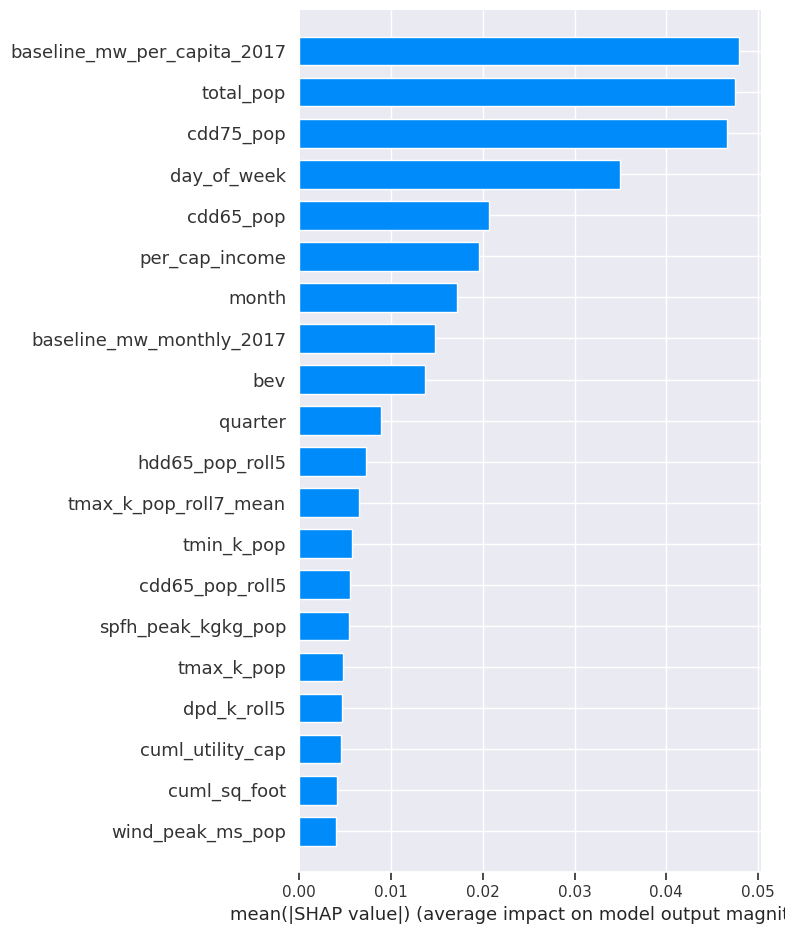

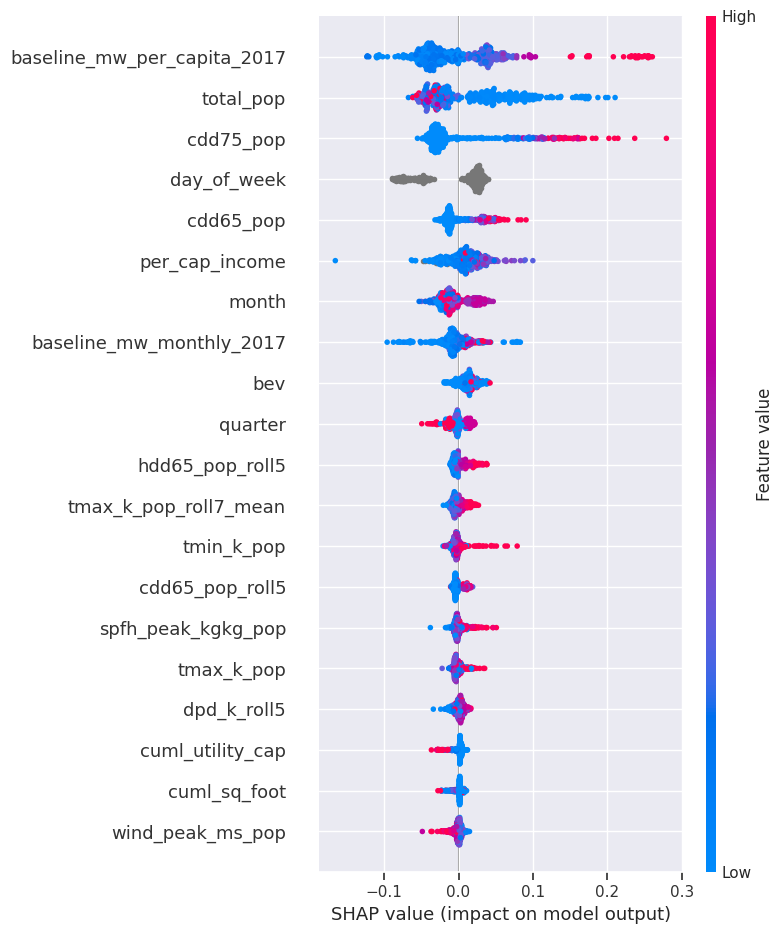

In [32]:
### Cell 11 — SHAP
explainer   = shap.TreeExplainer(model)
shap_sample = val_df[selected_features].sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar")
shap.summary_plot(shap_values, shap_sample)


In [ ]:
#!pip install mlflow

In [33]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.7 MB/s eta 0:00:00


In [34]:
import mlflow
import mlflow.lightgbm
import joblib, os, tempfile
from datetime import datetime

run_ts        = datetime.now().strftime('%Y%m%d_%H%M')
model_version = 'v4'
model_name    = f'lgbm_{target}_{model_version}_{run_ts}'

MODEL_DIR = '/content/drive/My Drive/210_capstone/models'
PRED_DIR  = '/content/drive/My Drive/210_capstone/predictions'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MODEL_DIR}/mlflow.db')
mlflow.set_experiment('climate-feat-lgbm-peak')

with mlflow.start_run(run_name=f'lgbm_v4_{target}'):

    # ── Params ────────────────────────────────────────────────────────────
    mlflow.log_params(params)
    mlflow.log_param('target',       target)
    mlflow.log_param('n_features',   len(selected_features))
    mlflow.log_param('best_iter',    best_iter)
    mlflow.log_param('run_ts',       run_ts)

    # ── Log-space RMSE ────────────────────────────────────────────────────
    mlflow.log_metric('rmse_log_val', rmse_val)

    # ── MWh metrics ───────────────────────────────────────────────────────
    mlflow.log_metric('rmse_mwh_val',        rmse_mwh(val_df))
    mlflow.log_metric('rmse_pct_mean_val',   pct_of_mean(val_df))
    mlflow.log_metric('pop_wtd_rmse_pct_val',pop_weighted_rmse_pct(val_df))

    # ── Log model ─────────────────────────────────────────────────────────
    mlflow.lightgbm.log_model(model, artifact_path='lgbm')

    # ── Feature list as artifact ──────────────────────────────────────────
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        f.write('\n'.join(selected_features))
        tmp = f.name
    mlflow.log_artifact(tmp, artifact_path='metadata')
    os.unlink(tmp)

    print(f'MLflow run logged — climate-feat-lgbm / {model_name}')
    print(f'  rmse_mwh_val:         {rmse_mwh(val_df):,.0f} MWh')
    print(f'  pop_wtd_rmse_pct_val: {pop_weighted_rmse_pct(val_df):.1f}%')

# ── Export ────────────────────────────────────────────────────────────────────
joblib.dump(model,             f'{MODEL_DIR}/{model_name}.pkl')
joblib.dump(selected_features, f'{MODEL_DIR}/{model_name}_features.pkl')
mobility_baseline.to_parquet(  f'{MODEL_DIR}/mobility_baseline_2019.parquet')

val_df['elec_per_capita_log_actual'] = val_df[target]
val_df['elec_per_capita_log_pred']   = preds_val

pred_cols = ['county', 'date', 'total_pop', 'max_daily_electricity',
             'actual_mwh', 'elec_per_capita_log_actual',
             'elec_per_capita_log_pred', 'preds_mwh']
val_df[pred_cols].to_parquet(f'{PRED_DIR}/{model_name}_preds_val.parquet', index=False)

print(f'\nExported:')
print(f'  {model_name}.pkl')
print(f'  {model_name}_features.pkl')
print(f'  mobility_baseline_2019.parquet')
print(f'  {model_name}_preds_val.parquet')

2026/03/04 07:11:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 07:11:24 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — climate-feat-lgbm / lgbm_max_elec_per_capita_log_v4_20260304_0711
  rmse_mwh_val:         141 MWh
  pop_wtd_rmse_pct_val: 12.0%

Exported:
  lgbm_max_elec_per_capita_log_v4_20260304_0711.pkl
  lgbm_max_elec_per_capita_log_v4_20260304_0711_features.pkl
  mobility_baseline_2019.parquet
  lgbm_max_elec_per_capita_log_v4_20260304_0711_preds_val.parquet


In [39]:
import joblib

# Load the v5 model you just trained
lgbm_model = joblib.load('/content/drive/My Drive/210_capstone/models/lgbm_max_elec_per_capita_log_v4_20260304_0711.pkl')
# (adjust path to wherever you saved it)

# Align test_df categories with training
def set_and_align_categories(train_df, test_df, cat_cols=["county", "day_of_week"]):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        test_df[c]  = test_df[c].astype("category")
        test_df[c]  = test_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, test_df

train_df, test_df = set_and_align_categories(train_df, test_df, cat_cols=["county", "day_of_week"])

# Use the v5 model you just trained (not v4)
# Don't load from disk - use the lgbm_model object already in memory
X_test = test_df[selected_features]  # Use selected_features from v5
preds_test_log = lgbm_model.predict(X_test)

test_df['preds_mwh'] = np.exp(preds_test_log) * test_df['total_pop']
test_df['actual_mwh'] = np.exp(test_df['max_elec_per_capita_log']) * test_df['total_pop']

# Metrics (with correct pop-weighted calculation)
ft2_rmse_lgbm = np.sqrt(mean_squared_error(test_df['actual_mwh'], test_df['preds_mwh']))
w = test_df['total_pop'].values
wrmse = np.sqrt(np.sum(w * (test_df['actual_mwh'] - test_df['preds_mwh'])**2) / np.sum(w))
wmean = np.average(test_df['actual_mwh'], weights=w)  # Population-weighted mean!
pop_wtd_lgbm = 100 * wrmse / wmean

print(f"\nLightGBM v5 (2017 baselines) TEST (2023):")
print(f"  RMSE: {ft2_rmse_lgbm:,.0f} MWh")
print(f"  Pop-wtd: {pop_wtd_lgbm:.1f}%")

print(f"\nFinal Comparison (TEST 2023):")
print(f"{'Metric':<25} {'Transformer':<20} {'LightGBM v5':<20}")
print("-"*70)
print(f"{'RMSE MWh':<25} {184:<20} {ft2_rmse_lgbm:<20.0f}")
print(f"{'Pop-wtd RMSE %':<25} {15.9:<20} {pop_wtd_lgbm:<20.1f}%")


LightGBM v5 (2017 baselines) TEST (2023):
  RMSE: 199 MWh
  Pop-wtd: 17.4%

Final Comparison (TEST 2023):
Metric                    Transformer          LightGBM v5         
----------------------------------------------------------------------
RMSE MWh                  184                  199                 
Pop-wtd RMSE %            15.9                 17.4                %


In [ ]:
# Debug - check the actual predictions
print("Prediction diagnostics:")
print(f"  preds_test_log range: {preds_test_log.min():.2f} to {preds_test_log.max():.2f}")
print(f"  preds_mwh range: {test_df['preds_mwh'].min():.0f} to {test_df['preds_mwh'].max():.0f}")
print(f"  actual_mwh range: {test_df['actual_mwh'].min():.0f} to {test_df['actual_mwh'].max():.0f}")

print(f"\n  preds_mwh mean: {test_df['preds_mwh'].mean():.0f}")
print(f"  actual_mwh mean: {test_df['actual_mwh'].mean():.0f}")

print(f"\n  NaNs in preds: {test_df['preds_mwh'].isna().sum()}")
print(f"  NaNs in actual: {test_df['actual_mwh'].isna().sum()}")

# Check a few rows
print("\nSample rows:")
print(test_df[['county', 'date', 'actual_mwh', 'preds_mwh']].head(20))

In [ ]:
# Correct pop-weighted RMSE calculation
def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['actual_mwh'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['actual_mwh'], weights=w)  # Population-weighted mean!
    return 100 * wrmse / wmean

pop_wtd_lgbm = pop_weighted_rmse_pct(test_df)

print(f"\n✓ LightGBM v4 TEST (2023):")
print(f"  RMSE: {ft2_rmse_lgbm:,.0f} MWh")
print(f"  Pop-wtd: {pop_wtd_lgbm:.1f}%")

print(f"\n{'='*70}")
print(f"FINAL COMPARISON (TEST 2023)")
print(f"{'='*70}")
print(f"{'Metric':<25} {'Transformer':<20} {'LightGBM v4':<20}")
print("-"*70)
print(f"{'RMSE MWh':<25} {184:<20} {ft2_rmse_lgbm:<20.0f}")
print(f"{'Pop-wtd RMSE %':<25} {15.9:<20} {pop_wtd_lgbm:<20.1f}%")